Insurance Claims


Dataset "Insurance Claims" trên Kaggle (tác giả litvinenko630 hoặc các biến thể phổ biến tương tự về dự đoán bảo hiểm xe cơ giới/bảo hiểm tổng hợp) là một tập dữ liệu kinh điển chuyên dùng cho bài toán Phân loại (Classification), Đánh giá rủi ro (Risk Assessment) và Phát hiện gian lận bảo hiểm (Fraud Detection)

1. Tổng quan về Dataset
Mục tiêu chính: Dự đoán xem một yêu cầu bồi thường (claim) có phải là gian lận (fraud) hay không, hoặc dự đoán xác suất xảy ra yêu cầu bồi thường dựa trên thông tin về khách hàng, hợp đồng và phương tiện.

Thách thức lớn nhất khi phân tích: Tập dữ liệu này thường gặp tình trạng mất cân bằng lớp (class imbalance) – nghĩa là số lượng các vụ bồi thường hợp pháp (non-fraud) chiếm đa số, trong khi số vụ gian lận (fraud) chiếm tỷ lệ rất nhỏ. Điều này đòi hỏi phải dùng các kỹ thuật xử lý như SMOTE, điều chỉnh trọng số lớp (class weights) hoặc dùng các metric đánh giá như Precision-Recall, F1-Score thay vì chỉ nhìn vào Accuracy.

2. Các nhóm thuộc tính (Features) chính trong Dataset

Các cột trong dataset thường được chia thành các nhóm thông tin chính sau:

A. Thông tin về Khách hàng (Policyholder Demographics)

age, customer_age: Tuổi của chủ hợp đồng.

months_as_customer: Thời gian (tính bằng tháng) khách hàng đã tham gia bảo hiểm tại công ty. Khách hàng mới thường có rủi ro hoặc hành vi khác biệt so với khách hàng lâu năm.

B. Thông tin về Hợp đồng bảo hiểm (Policy Details)

policy_number: Mã số định danh của hợp đồng.

policy_bind_date: Ngày ký kết hợp đồng.

policy_state: Bang/Khu vực đăng ký hợp đồng.

policy_csl (Combined Single Limit): Giới hạn bồi thường tối đa cho một sự cố (ví dụ: mức bảo hiểm cho thương tật cơ thể và thiệt hại tài sản).

policy_deductable: Mức khấu trừ (số tiền mà người mua bảo hiểm phải tự trả trước khi công ty bảo hiểm chi trả phần còn lại).

policy_annual_premium: Phí bảo hiểm đóng hàng năm.

C. Thông tin về Phương tiện và Sự cố (Vehicle & Incident Details)

vehicle_age: Tuổi đời của xe (ảnh hưởng đến hao mòn và khả năng hỏng hóc).

model, engine_type, fuel_type: Dòng xe, loại động cơ, loại nhiên liệu (xăng, dầu...).

airbags: Số lượng túi khí (đặc điểm an toàn của xe).

region_code, region_density: Mã vùng hoặc mật độ dân số nơi xảy ra sự cố/khách hàng sinh sống (khu vực đông đúc thường có tỷ lệ tai nạn cao hơn).

Các thông số kỹ thuật khác: Chiều dài, chiều rộng, bán kính quay vòng, trọng lượng tổng thể của xe.

D. Biến Mục tiêu (Target Variable)

fraud_reported hoặc claim_status: Biến nhãn (Label) quyết định bài toán. Thường nhận giá trị nhị phân (Y/N hoặc 1/0), cho biết yêu cầu bồi thường đó có bị phát hiện là gian lận hay không, hoặc trạng thái phê duyệt bồi thường.

3. Ứng dụng thực tế và Hướng khai thác (Use Cases)

Xây dựng mô hình Machine Learning dự đoán gian lận:

Sử dụng các thuật toán phân loại như Logistic Regression, Random Forest, XGBoost, LightGBM hoặc Neural Networks để dự đoán cột fraud_reported.

Xử lý dữ liệu mất cân bằng bằng kỹ thuật Undersampling/Oversampling.

Phân khúc khách hàng (Customer Segmentation):

Nhóm khách hàng theo độ tuổi, thời gian gắn bó, loại xe và mức phí bảo hiểm để tối ưu hóa chiến lược định giá (pricing strategy) và chính sách chăm sóc.

Quản trị rủi ro (Risk Assessment):

Xác định những yếu tố nào (ví dụ: loại xe, tuổi đời hợp đồng, khu vực địa lý) làm tăng cao khả năng xảy ra tổn thất để nhà bảo hiểm điều chỉnh hạn mức hoặc từ chối các hợp đồng có rủi ro quá cao.

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [178]:
# Cấu hình Pandas hiển thị tất cả các cột của DataFrame mà không bị ẩn bớt ở giữa
pd.set_option("display.max_columns", None)

# Thiết lập chiều rộng hiển thị tối đa trên một dòng ngang là 150 ký tự (tránh bị ngắt dòng rối mắt)
pd.set_option("display.width", 150)

# Cài đặt giao diện cho các biểu đồ Seaborn thành nền trắng có kèm các đường lưới (grid) dễ nhìn
sns.set_style("whitegrid")

In [179]:
df = pd.read_csv("Insurance claims data.csv")


In [180]:
df.shape
# trong pandas trả về một tuple (bộ giá trị) biểu diễn kích thước của DataFrame dưới dạng:
# (số_hàng, số_cột)

(58592, 41)

In [181]:
df.head(5)

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0


In [182]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera',
       'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight',
       'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert',
       'ncap_rating', 'claim_status'],
      dtype='object')

In [183]:
df.info()
# trong Pandas dùng để hiển thị tóm tắt cấu trúc tổng quan của DataFrame.
# Tổng số hàng
# Kiểu dữ liệu của DataFrame
# Số lượng giá trị không rỗng
# Kiểu dữ liệu của từng cột

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   subscription_length               58592 non-null  float64
 2   vehicle_age                       58592 non-null  float64
 3   customer_age                      58592 non-null  int64  
 4   region_code                       58592 non-null  object 
 5   region_density                    58592 non-null  int64  
 6   segment                           58592 non-null  object 
 7   model                             58592 non-null  object 
 8   fuel_type                         58592 non-null  object 
 9   max_torque                        58592 non-null  object 
 10  max_power                         58592 non-null  object 
 11  engine_type                       58592 non-null  object 
 12  airb

In [184]:
df["claim_status"].head()

0    0
1    0
2    0
3    0
4    0
Name: claim_status, dtype: int64

In [185]:
df["claim_status"].value_counts()
# đếm tần suất xuất hiện của từng giá trị duy nhất trong cột

claim_status
0    54844
1     3748
Name: count, dtype: int64

In [186]:
df.isna().sum()
# để đếm tổng số lượng giá trị bị thiếu (NaN/Null) cho từng cột trong DataFrame.

policy_id                           0
subscription_length                 0
vehicle_age                         0
customer_age                        0
region_code                         0
region_density                      0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
steering_type                       0
turning_radius                      0
length                              0
width                               0
gross_weight

In [187]:
df.isna().sum().sum()

0

In [188]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
58587    False
58588    False
58589    False
58590    False
58591    False
Length: 58592, dtype: bool

In [189]:
df.duplicated().sum()
# để đếm tổng số lượng các dòng bị trùng lặp hoàn toàn trong DataFrame.

0

In [190]:
(df['claim_status'].value_counts(normalize=True) *100).round(2)
# tính toán tỷ lệ phần trăm (%) của từng giá trị trong cột

claim_status
0    93.6
1     6.4
Name: proportion, dtype: float64

In [191]:
num_cols = df.select_dtypes(include = ["int64", "float64"]).columns.to_list()
# để lọc ra danh sách tên các cột có kiểu dữ liệu là số (số nguyên int64 và số thực float64) trong DataFrame và lưu chúng dưới dạng một danh sách (Python list).

In [192]:
num_cols

['subscription_length',
 'vehicle_age',
 'customer_age',
 'region_density',
 'airbags',
 'displacement',
 'cylinder',
 'turning_radius',
 'length',
 'width',
 'gross_weight',
 'ncap_rating',
 'claim_status']

In [193]:
obj_cols = df.select_dtypes(include=['object']).columns.to_list()
# để lọc ra danh sách tên các cột có kiểu dữ liệu dạng chuỗi (text/object) trong DataFrame và lưu chúng vào một Python list.

In [194]:
obj_cols

['policy_id',
 'region_code',
 'segment',
 'model',
 'fuel_type',
 'max_torque',
 'max_power',
 'engine_type',
 'is_esc',
 'is_adjustable_steering',
 'is_tpms',
 'is_parking_sensors',
 'is_parking_camera',
 'rear_brakes_type',
 'transmission_type',
 'steering_type',
 'is_front_fog_lights',
 'is_rear_window_wiper',
 'is_rear_window_washer',
 'is_rear_window_defogger',
 'is_brake_assist',
 'is_power_door_locks',
 'is_central_locking',
 'is_power_steering',
 'is_driver_seat_height_adjustable',
 'is_day_night_rear_view_mirror',
 'is_ecw',
 'is_speed_alert']

In [195]:
len(obj_cols)

28

In [196]:
len(num_cols)

13

In [197]:
num_cols.remove("claim_status")
obj_cols.remove("policy_id")

Ý nghĩa: Xóa cột "claim_status" ra khỏi danh sách các cột số (num_cols).

Lý do thực tế: Mặc dù cột claim_status có thể đang mang kiểu dữ liệu số (0 và 1), nhưng đây thực chất là biến mục tiêu (target/label) mà mô hình Machine Learning cần dự đoán, chứ không phải là đặc trưng đầu vào (features). Việc loại bỏ nó khỏi danh sách num_cols giúp bạn tránh nhầm lẫn khi chuẩn hóa dữ liệu hoặc đưa nhãn vào làm đầu vào huấn luyện mô hình.

Ý nghĩa: Xóa cột "policy_id" ra khỏi danh sách các cột dạng chữ (obj_cols).

Lý do thực tế: Cột policy_id thường là mã định danh duy nhất của từng hồ sơ hợp đồng (ví dụ: POL-001, POL-002,...). Dù nó có kiểu dữ liệu là chữ (object), nhưng nó không mang giá trị phân loại hay ý nghĩa học máy nào cả (vì mỗi dòng có một mã độc nhất, không lặp lại). Nếu đem đi mã hóa (encoding) sẽ làm nhiễu mô hình, do đó cần loại nó ra khỏi danh sách các đặc trưng phân loại cần xử lý.

In [198]:
# duyệt qua từng cột dạng chữ (obj_cols), kiểm tra mức độ đa dạng của dữ liệu trong từng cột đó và in ra màn hình một cách rất ngăn nắp

for col in obj_cols:
    uniques = df[col].unique() #Lấy ra toàn bộ các giá trị duy nhất (không bị lặp lại) có trong cột đó.
    print(f"{col:35s} -- unique values: {df[col].nunique():3d} - sample: {uniques[:5]}")

region_code                         -- unique values:  22 - sample: ['C8' 'C2' 'C10' 'C13' 'C7']
segment                             -- unique values:   6 - sample: ['C2' 'C1' 'A' 'B2' 'B1']
model                               -- unique values:  11 - sample: ['M4' 'M9' 'M1' 'M5' 'M7']
fuel_type                           -- unique values:   3 - sample: ['Diesel' 'CNG' 'Petrol']
max_torque                          -- unique values:   9 - sample: ['250Nm@2750rpm' '200Nm@1750rpm' '60Nm@3500rpm' '200Nm@3000rpm'
 '113Nm@4400rpm']
max_power                           -- unique values:   9 - sample: ['113.45bhp@4000rpm' '97.89bhp@3600rpm' '40.36bhp@6000rpm'
 '88.77bhp@4000rpm' '88.50bhp@6000rpm']
engine_type                         -- unique values:  11 - sample: ['1.5 L U2 CRDi' 'i-DTEC' 'F8D Petrol Engine' '1.5 Turbocharged Revotorq'
 '1.2 L K Series Engine']
is_esc                              -- unique values:   2 - sample: ['Yes' 'No']
is_adjustable_steering              -- unique values: 

In [199]:
binary_cols = [c for c in obj_cols if set(df[c].unique()) <= {"Yes", "No"}]
# lọc ra danh sách các cột nhị phân (binary columns) từ nhóm các cột dạng chữ (obj_cols), cụ thể là những cột chỉ chứa các giá trị "Yes" và "No" (hoặc chỉ có một trong hai giá trị này).

In [200]:
binary_cols

['is_esc',
 'is_adjustable_steering',
 'is_tpms',
 'is_parking_sensors',
 'is_parking_camera',
 'is_front_fog_lights',
 'is_rear_window_wiper',
 'is_rear_window_washer',
 'is_rear_window_defogger',
 'is_brake_assist',
 'is_power_door_locks',
 'is_central_locking',
 'is_power_steering',
 'is_driver_seat_height_adjustable',
 'is_day_night_rear_view_mirror',
 'is_ecw',
 'is_speed_alert']

In [201]:
# để phân tích mức độ ảnh hưởng của từng cột nhị phân (binary_cols) đến tỷ lệ xảy ra khiếu nại bảo hiểm (claim_status), qua đó đánh giá xem cột nào có khả năng phân biệt tốt nhất.

results = []

for col in binary_cols:
    rates = df.groupby(col)["claim_status"].mean() *100
    gap = abs(rates.get("Yes", 0) - rates.get("No", 0))
    results.append((col, rates.get("No", np.nan), rates.get("Yes", np.nan), gap))

3. rates = df.groupby(col)["claim_status"].mean() * 100
Ý nghĩa:

df.groupby(col)["claim_status"].mean(): Gom nhóm dữ liệu theo từng giá trị của cột (tức là nhóm các dòng có "Yes" riêng và "No" riêng), sau đó tính giá trị trung bình (mean) của cột claim_status. Vì claim_status nhận giá trị 0 hoặc 1, nên giá trị trung bình này chính là tỷ lệ phần trăm xảy ra khiếu nại (Claim Rate).

* 100: Đổi tỷ lệ đó ra dạng phần trăm (%).

Kết quả: rates sẽ là một Series chứa tỷ lệ % khiếu nại tương ứng với từng giá trị "Yes" và "No" của cột đó.

4. gap = abs(rates.get("Yes", 0) - rates.get("No", 0))
Ý nghĩa:

rates.get("Yes", 0) và rates.get("No", 0): Lấy tỷ lệ % của nhóm "Yes" và nhóm "No", nếu vì lý do nào đó mà giá trị đó không tồn tại trong bảng thì mặc định trả về 0.

abs(...): Lấy giá trị tuyệt đối của phép trừ.

Kết quả: gap chính là khoảng chênh lệch tuyệt đối (%) về tỷ lệ khiếu nại giữa hai nhóm "Yes" và "No".

5. results.append((col, rates.get("No", np.nan), rates.get("Yes", np.nan), gap))
Ý nghĩa: Đóng gói toàn bộ kết quả vừa tính được của cột hiện tại thành một bộ giá trị (tuple) gồm 4 thông tin:

col: Tên cột đang xét.

rates.get("No", np.nan): Tỷ lệ % khiếu nại của nhóm "No".

rates.get("Yes", np.nan): Tỷ lệ % khiếu nại của nhóm "Yes".

gap: Mức độ chênh lệch giữa hai nhóm.

In [202]:
results

[('is_esc', 6.347192157448185, 6.5050812455844795, 0.15788908813629465),
 ('is_adjustable_steering',
  5.97416110292205,
  6.671170410403649,
  0.6970093074815988),
 ('is_tpms', 6.38713151164356, 6.42745042088743, 0.04031890924387049),
 ('is_parking_sensors',
  5.39401601348504,
  6.439104217435386,
  1.0450882039503453),
 ('is_parking_camera',
  6.413847187990142,
  6.370150297098917,
  0.043696890891225415),
 ('is_front_fog_lights',
  6.057411612066169,
  6.643480311247347,
  0.5860686991811779),
 ('is_rear_window_wiper',
  6.355382619974059,
  6.49840783111216,
  0.14302521113810052),
 ('is_rear_window_washer',
  6.355382619974059,
  6.49840783111216,
  0.14302521113810052),
 ('is_rear_window_defogger',
  6.350290201433936,
  6.483061174750183,
  0.132770973316247),
 ('is_brake_assist',
  6.1025932235472276,
  6.638282002672717,
  0.5356887791254898),
 ('is_power_door_locks',
  6.13356439933156,
  6.496995404736657,
  0.3634310054050971),
 ('is_central_locking',
  6.13356439933156,


('is_speed_alert', 4.132, 6.411, 2.279):

Xe Không có cảnh báo tốc độ (is_speed_alert = No): Tỷ lệ bồi thường là 4.13%.
Xe Có cảnh báo tốc độ (is_speed_alert = Yes): Tỷ lệ bồi thường là 6.41%.
Chênh lệch (gap): 2.28% (đây là tính năng có sự phân hóa tỷ lệ bồi thường cao nhất trong danh sách).

In [203]:
# để tổng hợp toàn bộ kết quả phân tích độ chênh lệch mà bạn vừa tính ở bước trước thành một bảng báo cáo gọn gàng, sắp xếp theo mức độ quan trọng và in ra màn hình.
gap_df = pd.DataFrame(results, columns = ["feature", "claim_rate_No", "claim_rate_Yes", "gap"]).sort_values("gap", ascending=False)
print(gap_df.round(2).to_string(index = False))

                         feature  claim_rate_No  claim_rate_Yes  gap
                  is_speed_alert           4.13            6.41 2.28
              is_parking_sensors           5.39            6.44 1.05
          is_adjustable_steering           5.97            6.67 0.70
             is_front_fog_lights           6.06            6.64 0.59
                 is_brake_assist           6.10            6.64 0.54
is_driver_seat_height_adjustable           6.09            6.62 0.53
   is_day_night_rear_view_mirror           6.24            6.65 0.40
               is_power_steering           6.04            6.40 0.37
              is_central_locking           6.13            6.50 0.36
                          is_ecw           6.13            6.50 0.36
             is_power_door_locks           6.13            6.50 0.36
                          is_esc           6.35            6.51 0.16
           is_rear_window_washer           6.36            6.50 0.14
            is_rear_window_wiper  

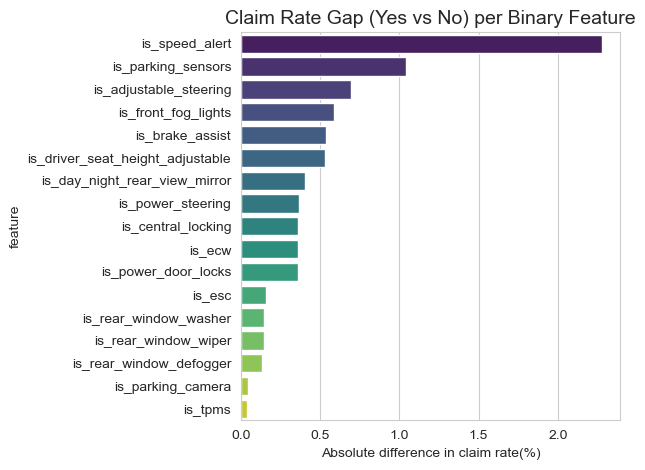

In [204]:
sns.barplot(data = gap_df, y = "feature", x= "gap", palette="viridis")
plt.title("Claim Rate Gap (Yes vs No) per Binary Feature", fontsize = 14)
plt.xlabel("Absolute difference in claim rate(%)")
plt.tight_layout()
plt.show()

In [205]:
df.groupby("claim_status")[num_cols].mean().T.round(2)
# dùng để tính giá trị trung bình của tất cả các cột số (num_cols) theo từng nhóm trạng thái yêu cầu bồi thường (claim_status), sau đó đảo ngược bảng và làm tròn kết quả để dễ dàng so sánh nhanh.

claim_status,0,1
subscription_length,6.03,7.36
vehicle_age,1.40,1.27
customer_age,44.78,45.41
region_density,18909.07,17623.82
airbags,3.14,3.16
displacement,1161.82,1170.18
cylinder,3.63,3.65
turning_radius,4.85,4.86
length,3849.95,3858.21
width,1671.94,1676.50


Cột 0: Nhóm khách hàng KHÔNG yêu cầu bồi thường bảo hiểm (claim_status = 0).
Cột 1: Nhóm khách hàng CÓ yêu cầu bồi thường bảo hiểm (claim_status = 1).

In [206]:
cat_to_explore = ["region_code", "model", "segment", "fuel_type", "transmission_type", "steering_type"]

for col in cat_to_explore:
    grp = df.groupby(col)["claim_status"].agg(["count", "mean"]).sort_values("count", ascending=False)

    grp["mean"] = (grp["mean"] *100).round(2)

    print(f"---{col}---")

    print(grp.head(10))

---region_code---
             count  mean
region_code             
C8           13654  6.99
C2            7342  7.08
C5            6979  5.77
C3            6101  7.10
C14           3660  7.68
C13           3423  5.70
C10           3155  4.69
C9            2734  4.97
C7            2167  5.03
C12           1589  5.48
---model---
       count  mean
model             
M1     14948  6.14
M4     14018  6.43
M6     13776  6.82
M8      4173  5.85
M7      2940  6.84
M3      2373  5.39
M9      2114  6.29
M5      1598  7.26
M10     1209  6.04
M2      1080  7.41
---segment---
         count  mean
segment             
B2       18314  6.86
A        17321  6.04
C2       14018  6.43
B1        4173  5.85
C1        3557  6.41
Utility   1209  6.04
---fuel_type---
           count  mean
fuel_type             
Petrol     20532  6.64
CNG        20330  6.07
Diesel     17730  6.49
---transmission_type---
                   count  mean
transmission_type             
Manual             38181  6.39
Automatic   

để phân tích sâu các cột phân loại quan trọng (cat_to_explore) nhằm xem xét phân bố số lượng hồ sơ cũng như tỷ lệ xảy ra khiếu nại (claim_status) cho từng nhóm giá trị cụ thể bên trong các cột đó.

3. grp = df.groupby(col)["claim_status"].agg(["count", "mean"]).sort_values("count", ascending=False)
Ý nghĩa:

df.groupby(col)["claim_status"]: Gom nhóm dữ liệu theo từng giá trị riêng biệt có trong cột hiện tại (ví dụ: nhóm theo từng dòng xe model hoặc từng loại nhiên liệu fuel_type).

.agg(["count", "mean"]): Tính đồng thời 2 chỉ số cho mỗi nhóm:

count: Tổng số lượng hồ sơ (tần suất xuất hiện) của giá trị đó trong dataset.

mean: Tỷ lệ trung bình của cột claim_status (vì claim_status nhận giá trị 0 hoặc 1, nên giá trị trung bình này chính là tỷ lệ khiếu nại, chạy từ 0.0 đến 1.0).

.sort_values("count", ascending=False): Sắp xếp các nhóm theo thứ tự số lượng hồ sơ từ nhiều nhất xuống ít nhất để ưu tiên xem xét những giá trị phổ biến trước.

4. grp["mean"] = (grp["mean"] * 100).round(2)
Ý nghĩa: Chuyển đổi cột giá trị trung bình (mean) thành tỷ lệ phần trăm (%) và làm tròn đến 2 chữ số thập phân, giúp báo cáo trực quan và dễ đọc hơn (ví dụ: đổi 0.1523 thành 15.23%).

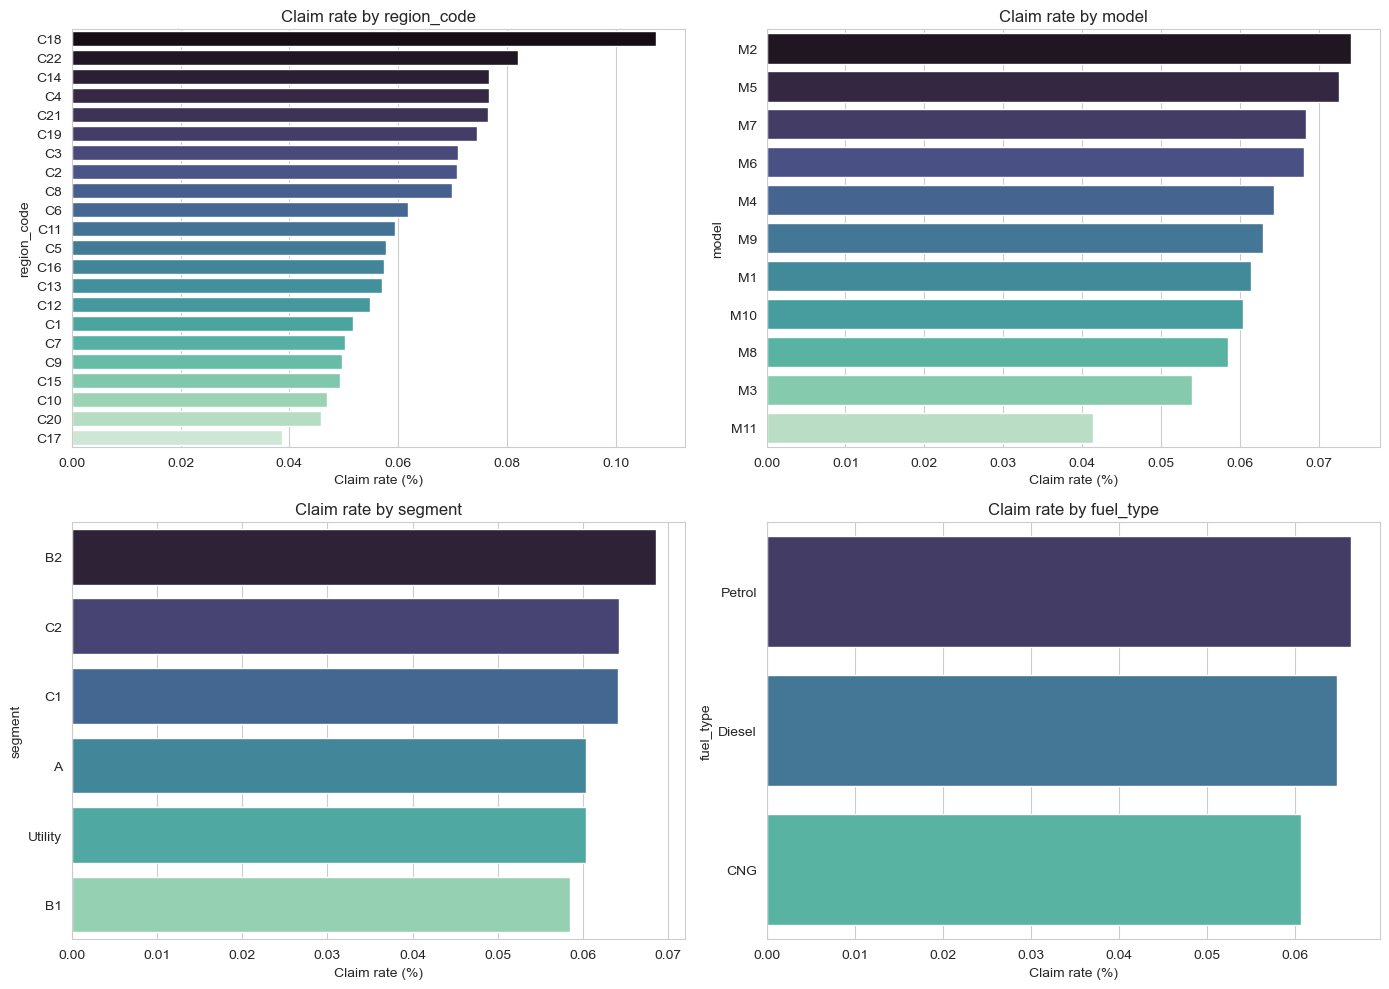

In [207]:
fig, axes = plt.subplots(2,2, figsize = (14,10))
for ax, col in zip(axes.flat, ["region_code", "model", "segment", "fuel_type"]):
    grp = df.groupby(col)["claim_status"].mean().sort_values(ascending=False)

    sns.barplot(x=grp.values, y=grp.index, ax=ax, palette="mako")
    ax.set_title(f"Claim rate by {col}")
    ax.set_xlabel("Claim rate (%)")

plt.tight_layout()
plt.show()

In [208]:
# để tính toán ma trận tương quan (Correlation Matrix) giữa tất cả các cột số (num_cols) và biến mục tiêu (claim_status).
corr_cols = num_cols + ["claim_status"]

corr = df[corr_cols].corr()

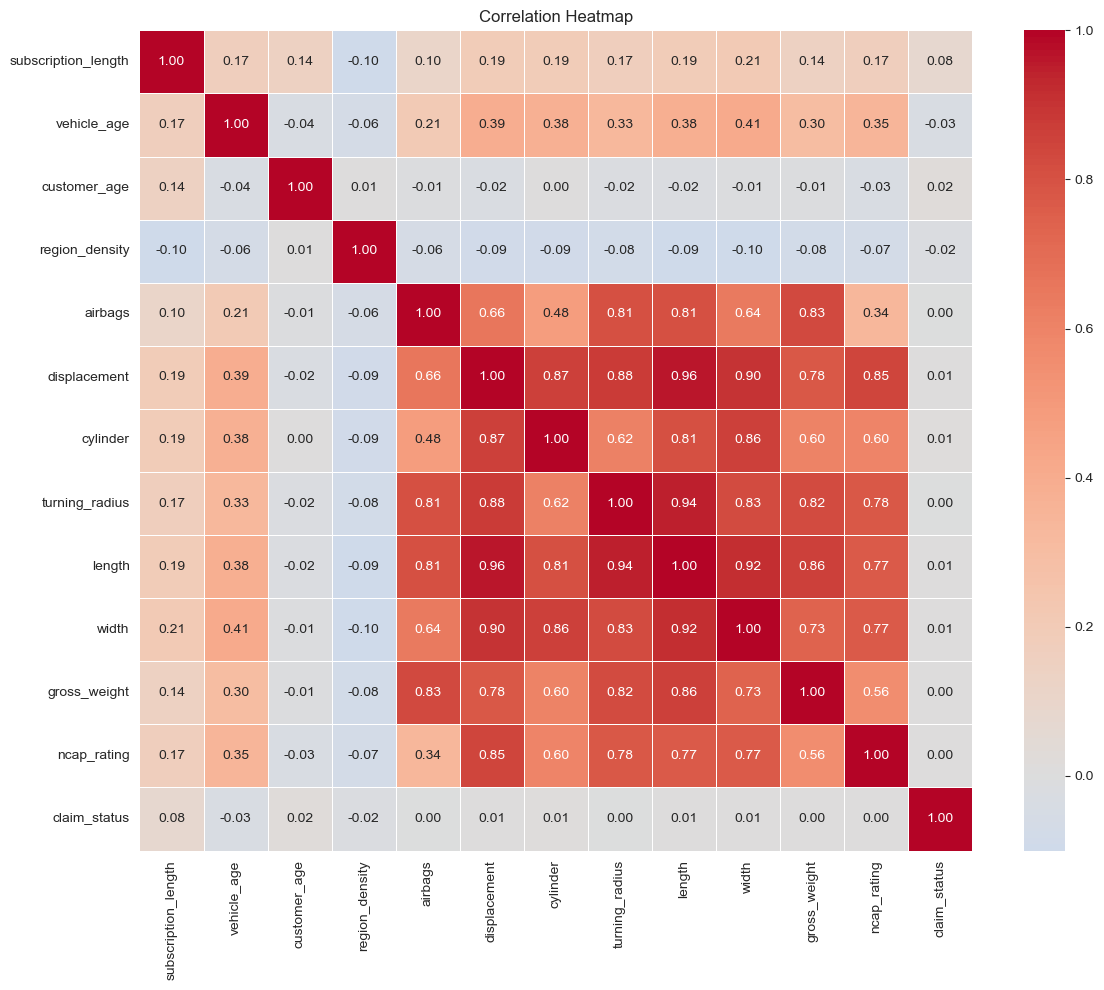

In [209]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center = 0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Kết quả trả về là một bảng vuông (ma trận tương quan) có giá trị dao động từ -1 đến 1:

Giá trị gần 1: Tương quan thuận mạnh (một biến tăng thì biến kia cũng tăng).

Giá trị gần -1: Tương quan nghịch mạnh (một biến tăng thì biến kia giảm).

Giá trị quanh 0: Không có tuyến tính tương quan.

In [210]:
# để kiểm tra chi tiết phân phối thống kê (Descriptive Statistics) của ba cột dữ liệu số quan trọng (subscription_length, vehicle_age, customer_age) nhằm phát hiện các giá trị bất thường (outliers), điểm dữ liệu cực biên hoặc lỗi nhập liệu.

for col in ["subscription_length", "vehicle_age", "customer_age"]:
    print(f"---{col}---")
    print(df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

---subscription_length---
count    58592.000000
mean         6.111688
std          4.142790
min          0.000000
1%           0.100000
5%           0.400000
25%          2.100000
50%          5.700000
75%         10.400000
95%         12.000000
99%         12.400000
max         14.000000
Name: subscription_length, dtype: float64
---vehicle_age---
count    58592.000000
mean         1.388473
std          1.134413
min          0.000000
1%           0.000000
5%           0.000000
25%          0.400000
50%          1.200000
75%          2.200000
95%          3.400000
99%          4.200000
max         20.000000
Name: vehicle_age, dtype: float64
---customer_age---
count    58592.000000
mean        44.823935
std          6.935604
min         35.000000
1%          35.000000
5%          35.000000
25%         39.000000
50%         44.000000
75%         49.000000
95%         58.000000
99%         63.000000
max         75.000000
Name: customer_age, dtype: float64


Kiểm tra biên giới (Min/Max và Percentile 1%/99%): Xem xét liệu có xuất hiện các giá trị vô lý hay không (ví dụ: tuổi khách hàng là 150 tuổi, thời gian tham gia âm, hoặc tuổi xe lên tới hàng trăm năm).

Đánh giá độ lệch dữ liệu (Skewness): So sánh giữa giá trị trung vị (50% hay median) và giá trị trung bình (mean) xem phân phối dữ liệu có bị lệch trái hay lệch phải không, từ đó quyết định xem có cần chuẩn hóa hoặc xử lý ngoại lai (như dùng kỹ thuật capping/clipping) trước khi đưa vào mô hình Machine Learning hay không.

3. print(df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
Ý nghĩa:

df[col].describe(...): Hàm describe() mặc định chỉ cung cấp một số thông số cơ bản (count, mean, std, min, 25%, 50%, 75%, max).

percentiles=[.01, .05, .25, .5, .75, .95, .99]: Mở rộng thêm các mốc phân vị (percentiles) từ rất nhỏ (1%, 5%) cho đến rất lớn (95%, 99%).

In [211]:
print(f"vehicle_age > 10: ", (df["vehicle_age"] > 10).sum())

vehicle_age > 10:  6


In [212]:
(df["subscription_length"] == 0).sum()

276

In [213]:
import warnings 
warnings.filterwarnings("ignore")

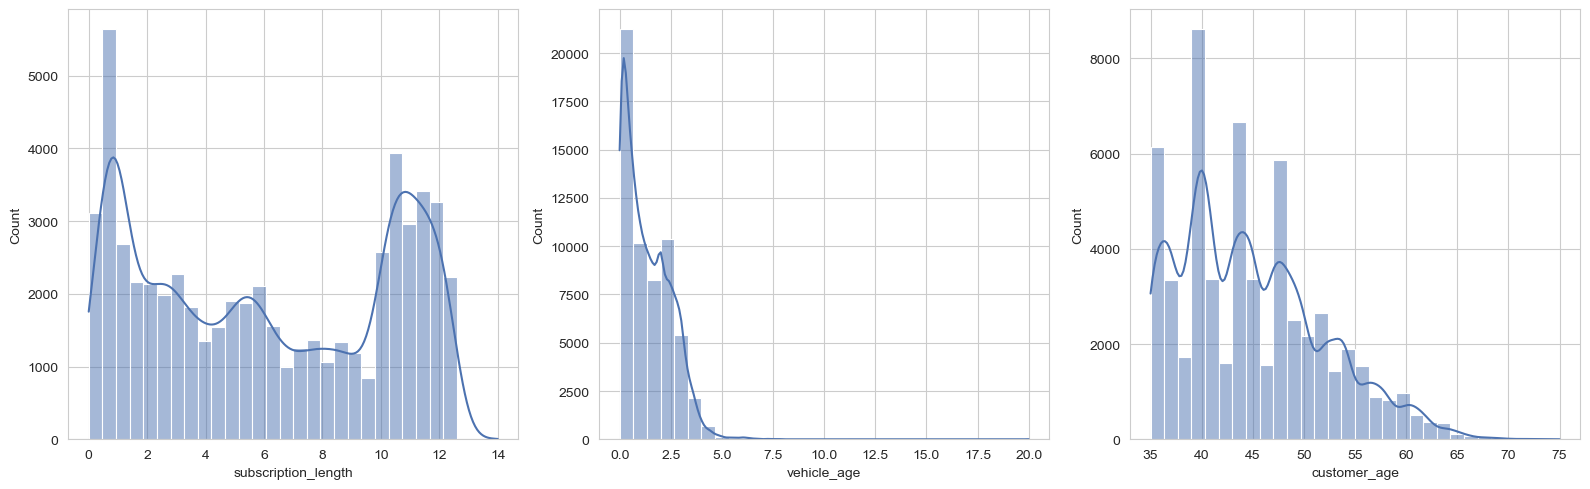

In [214]:
fix, axes = plt.subplots(1, 3, figsize = (16,5))

for ax, col in zip(axes, ["subscription_length", "vehicle_age", "customer_age"]):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#4C72B0")

plt.tight_layout()
plt.show()

vẽ biểu đồ phân phối (Histogram kết hợp đường cong mật độ KDE) cho ba cột dữ liệu số quan trọng (subscription_length, vehicle_age, customer_age) nhằm trực quan hóa hình dạng phân phối của dữ liệu.

In [215]:
df[["max_torque", "max_power"]]

,max_torque,max_power
0,250Nm@2750rpm,113.45bhp@4000rpm
1,200Nm@1750rpm,97.89bhp@3600rpm
2,250Nm@2750rpm,113.45bhp@4000rpm
3,60Nm@3500rpm,40.36bhp@6000rpm
4,200Nm@3000rpm,88.77bhp@4000rpm
...,...,...
58587,113Nm@4400rpm,88.50bhp@6000rpm
58588,250Nm@2750rpm,113.45bhp@4000rpm
58589,113Nm@4400rpm,88.50bhp@6000rpm
58590,113Nm@4400rpm,88.50bhp@6000rpm


In [216]:
torque_parsed = df["max_torque"].str.extract(r"([\d.]+)Nm@([\d.]+)rpm").astype(float)

trích xuất và tách thông tin kỹ thuật phức tạp từ một cột dạng văn bản (chuỗi) trong tập dữ liệu ô tô/bảo hiểm (thường là cột mô tả lực kéo max_torque) thành hai cột dữ liệu số riêng biệt để dễ dàng phân tích hoặc đưa vào mô hình.

In [217]:
torque_parsed

,0,1
0,250.0,2750.0
1,200.0,1750.0
2,250.0,2750.0
3,60.0,3500.0
4,200.0,3000.0
...,...,...
58587,113.0,4400.0
58588,250.0,2750.0
58589,113.0,4400.0
58590,113.0,4400.0


In [218]:
power_parsed = df["max_power"].str.extract(r"([\d.]+)bhp@([\d.]+)rpm").astype(float)

In [219]:
power_parsed

,0,1
0,113.45,4000.0
1,97.89,3600.0
2,113.45,4000.0
3,40.36,6000.0
4,88.77,4000.0
...,...,...
58587,88.50,6000.0
58588,113.45,4000.0
58589,88.50,6000.0
58590,88.50,6000.0


In [220]:
# gan lai vao truogn moi sau khi trich xuat
df["torque_Nm"] = torque_parsed[0]
df["torque_rpm"] = torque_parsed[1]

df["power_bhp"] = power_parsed[0]
df["power_rpm"] = power_parsed[1]

In [221]:
df

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status,torque_Nm,torque_rpm,power_bhp,power_rpm
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,No,Yes,No,Yes,Yes,Drum,1498,4,Manual,Electric,4.9,3995,1695,1051,Yes,No,No,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0,200.0,1750.0,97.89,3600.0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
3,POL018146,5.2,0.4,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,Power,4.6,3445,1515,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0,60.0,3500.0,40.36,6000.0
4,POL049011,10.1,1.0,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,No,Yes,No,Yes,No,Drum,1497,4,Manual,Electric,5.0,3990,1755,1490,No,No,No,No,No,Yes,Yes,Yes,No,No,Yes,Yes,5,0,200.0,3000.0,88.77,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,POL019269,10.6,2.6,48,C5,34738,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0
58588,POL001254,2.3,2.2,37,C3,4076,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,Yes,Yes,Yes,Yes,Yes,Disc,1493,4,Automatic,Power,5.2,4300,1790,1720,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0,250.0,2750.0,113.45,4000.0
58589,POL019859,6.6,2.2,35,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0
58590,POL014061,4.1,3.6,44,C8,8794,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,2,No,Yes,No,Yes,No,Drum,1197,4,Manual,Electric,4.8,3845,1735,1335,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0,113.0,4400.0,88.50,6000.0


In [222]:
torque_parsed.isna().any(axis=1).sum()

0

dùng để đếm tổng số lượng dòng (rows) bị thiếu dữ liệu (chứa giá trị NaN) trong bảng torque_parsed sau khi bạn thực hiện bước trích xuất thông tin bằng biểu thức chính quy (Regex).

In [223]:
power_parsed.isna().any(axis=1).sum()

0

In [224]:
df.columns

Index(['policy_id', 'subscription_length', 'vehicle_age', 'customer_age', 'region_code', 'region_density', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera',
       'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'steering_type', 'turning_radius', 'length', 'width', 'gross_weight',
       'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert',
       'ncap_rating', 'claim_status', 'torque_Nm', 'torque_rpm', 'power_bhp', 'power_rpm'],
      dtype='object')

In [225]:
drop_cols = [
    'policy_id', 'segment', 'engine_type', 'fuel_type', 'max_torque', 'max_power',
    'torque_Nm', 'torque_rpm', 'power_bhp', 'power_rpm',
    'displacement', 'cylinder', 'turning_radius', 'length', 'width',
    'gross_weight', 'ncap_rating', 'airbags', 'steering_type',
    'transmission_type', 'rear_brakes_type', 'is_esc', 'is_adjustable_steering',
    'region_code',
    'is_tpms', 'is_parking_camera', 'is_rear_window_wiper', 'is_rear_window_washer',
    'is_rear_window_defogger', 'is_central_locking', 'is_power_door_locks', 'is_ecw'
]

In [226]:
df_clean = df.drop(columns=drop_cols)

In [227]:
df_clean.columns

Index(['subscription_length', 'vehicle_age', 'customer_age', 'region_density', 'model', 'is_parking_sensors', 'is_front_fog_lights',
       'is_brake_assist', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_speed_alert',
       'claim_status'],
      dtype='object')

In [228]:
df_clean.shape

(58592, 13)

In [229]:
binary_final = [
    'is_parking_sensors',
    'is_front_fog_lights',
    'is_brake_assist',
    'is_power_steering',
    'is_driver_seat_height_adjustable',
    'is_day_night_rear_view_mirror',
    'is_speed_alert',
]

for col in binary_final:
    df_clean[col] = df_clean[col].map({"Yes": 1, "No": 0})

để chuyển đổi định dạng dữ liệu của một loạt các cột nhị phân (binary_final) từ dạng chữ ("Yes" / "No") sang dạng số nguyên (1 / 0) trong bảng dữ liệu sạch (df_clean).

In [230]:
df_clean

,subscription_length,vehicle_age,customer_age,region_density,model,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,claim_status
0,9.3,1.2,41,8794,M4,1,1,1,1,1,0,1,0
1,8.2,1.8,35,27003,M9,1,1,0,1,1,1,1,0
2,9.5,0.2,44,8794,M4,1,1,1,1,1,0,1,0
3,5.2,0.4,44,73430,M1,1,0,0,1,0,0,1,0
4,10.1,1.0,56,5410,M5,1,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,M6,1,1,1,1,1,1,1,0
58588,2.3,2.2,37,4076,M4,1,1,1,1,1,0,1,0
58589,6.6,2.2,35,8794,M6,1,1,1,1,1,1,1,0
58590,4.1,3.6,44,8794,M6,1,1,1,1,1,1,1,0


In [231]:
df_model = pd.get_dummies(df_clean, columns=["model"], drop_first=True)


dùng để chuyển đổi cột phân loại nhiều giá trị (model - dòng xe) thành các cột số nhị phân (One-Hot Encoding) để đưa vào mô hình Machine Learning.

pd.get_dummies(...): Hàm của thư viện Pandas dùng để thực hiện mã hóa One-Hot (One-Hot Encoding). Nó sẽ biến một cột chứa các giá trị chữ (ví dụ: các dòng xe khác nhau như Model A, Model B, Model C) thành một loạt các cột dạng cờ (dummy/indicator columns), mỗi cột tương ứng với một giá trị và chỉ nhận giá trị 0 hoặc 1.columns=["model"]: Chỉ định rõ ràng rằng thao tác mã hóa này chỉ áp dụng riêng cho cột model.drop_first=True: Loại bỏ cột đầu tiên trong tổng số các cột mới được tạo ra.Ý nghĩa thực tế: Giúp tránh hiện tượng đa cộng tuyến hoàn hảo (multicollinearity) trong toán học (còn gọi là bẫy biến giả - Dummy Variable Trap). Nếu một bài toán có $K$ nhóm dòng xe, ta chỉ cần dùng $K-1$ cột nhị phân để biểu diễn hoàn toàn thông tin đó, vì nếu tất cả $K-1$ cột đều bằng 0 thì tự động ta biết được đó là nhóm còn lại.

In [232]:
df_model

,subscription_length,vehicle_age,customer_age,region_density,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,claim_status,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9
0,9.3,1.2,41,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
1,8.2,1.8,35,27003,1,1,0,1,1,1,1,0,False,False,False,False,False,False,False,False,False,True
2,9.5,0.2,44,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
3,5.2,0.4,44,73430,1,0,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False
4,10.1,1.0,56,5410,1,0,0,1,0,0,1,0,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58588,2.3,2.2,37,4076,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
58589,6.6,2.2,35,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58590,4.1,3.6,44,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False


In [233]:
df_model

,subscription_length,vehicle_age,customer_age,region_density,is_parking_sensors,is_front_fog_lights,is_brake_assist,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_speed_alert,claim_status,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9
0,9.3,1.2,41,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
1,8.2,1.8,35,27003,1,1,0,1,1,1,1,0,False,False,False,False,False,False,False,False,False,True
2,9.5,0.2,44,8794,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
3,5.2,0.4,44,73430,1,0,0,1,0,0,1,0,False,False,False,False,False,False,False,False,False,False
4,10.1,1.0,56,5410,1,0,0,1,0,0,1,0,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58587,10.6,2.6,48,34738,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58588,2.3,2.2,37,4076,1,1,1,1,1,0,1,0,False,False,False,False,True,False,False,False,False,False
58589,6.6,2.2,35,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False
58590,4.1,3.6,44,8794,1,1,1,1,1,1,1,0,False,False,False,False,False,False,True,False,False,False


In [234]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns= ["claim_status"])
y = df_model["claim_status"]

tách tập dữ liệu thành hai phần riêng biệt: Ma trận đặc trưng đầu vào (X) và Biến mục tiêu cần dự đoán (y), đây là bước chuẩn bị cốt lõi ngay trước khi đưa dữ liệu vào thuật toán Machine Learning.

In [235]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

chia tập dữ liệu (X và y) thành hai phần riêng biệt: Tập huấn luyện (Train) và Tập kiểm thử (Test) để chuẩn bị cho quá trình huấn luyện mô hình Machine Learning.

train_test_split(X, y, ...): Hàm lấy ngẫu nhiên các dòng từ tập dữ liệu gốc và chia thành 4 biến đầu ra: X_train, X_test, y_train, y_test.

test_size=0.2: Chỉ định tỷ lệ chia dữ liệu — 20% dữ liệu sẽ được tách ra làm tập kiểm thử (X_test, y_test) để đánh giá mô hình ở bước cuối, và 80% dữ liệu còn lại dùng để huấn luyện (X_train, y_train).

stratify=y: Đây là tham số cực kỳ quan trọng đối với bài toán dự đoán gian lận bảo hiểm (Insurance Claims - thường là bài toán có dữ liệu mất cân bằng nghiêm trọng, ví dụ số ca gian lận rất ít so với số ca bình thường). Tham số này đảm bảo rằng tỷ lệ nhãn 0 và 1 trong cả tập Train và tập Test sẽ giữ nguyên tỷ lệ y hệt như tập dữ liệu gốc, tránh việc tập test vô tình không có hoặc có quá ít nhãn 1 khiến việc đánh giá mô hình bị sai lệch.

In [236]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

scale_pos_weight

14.634756504336224

tính toán trọng số lớp (scale_pos_weight) nhằm xử lý bài toán dữ liệu mất cân bằng (Imbalanced Data) – một vấn đề rất phổ biến trong các bài toán dự đoán gian lận bảo hiểm (khi mà số lượng hồ sơ bình thường 0 chiếm đại đa số, còn số lượng hồ sơ gian lận 1 lại cực kỳ ít).

In [237]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier

1. DecisionTreeClassifier (Cây quyết định đơn lẻ)
Bản chất: Xây dựng một cây quyết định duy nhất dựa trên việc chọn các điều kiện chia tách tối ưu (dựa trên độ lợi thông tin Information Gain hoặc Gini Impurity).

Ưu điểm: Cực kỳ dễ hiểu, trực quan, tốc độ huấn luyện nhanh.

Nhược điểm: Rất dễ bị quá khớp (overfitting) nếu để cây mọc quá sâu mà không giới hạn độ sâu (max_depth) hoặc số lượng lá tối thiểu. Thường ít khi được dùng đơn lẻ trong các bài toán thực tế cạnh tranh vì độ ổn định kém.

2. RandomForestClassifier (Rừng ngẫu nhiên)
Bản chất: Là tập hợp của hàng trăm cây quyết định đơn lẻ (DecisionTreeClassifier). Mỗi cây được huấn luyện trên một tập dữ liệu con lấy mẫu ngẫu nhiên (Bootstrap) và chỉ xét một tập con các đặc trưng tại mỗi nút chia. Kết quả cuối cùng là sự "bỏ phiếu" (voting) từ tất cả các cây.

Ưu điểm: Rất mạnh mẽ, ổn định cao, ít bị overfitting hơn cây đơn lẻ, xử lý tốt dữ liệu nhiễu và không cần chuẩn hóa dữ liệu (scaling).

Cách xử lý mất cân bằng: Bạn có thể truyền thêm tham số class_weight="balanced" khi khởi tạo để mô hình tự động cân bằng trọng số cho lớp thiểu số (lớp 1 gian lận).

### 3. `XGBRFClassifier` (XGBoost Random Forest)
* **Bản chất:** Đây là một biến thể của thư viện XGBoost nhưng hoạt động theo cơ chế của Random Forest (thay vì cơ chế Boosting tuần tự thông thường). Nó kết hợp sức mạnh của việc xây dựng các cây ngẫu nhiên song song với hệ thống tối ưu hóa tốc độ và độ chính xác của XGBoost.
* **Ưu điểm:** Kết hợp được tốc độ, khả năng tối ưu hóa hàm mất mát của XGBoost với tính ổn định chống overfitting của Random Forest.

In [238]:
dt = DecisionTreeClassifier(
    max_depth = 4, class_weight="balanced"
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4)

DecisionTreeClassifier(max_depth=4, class_weight="balanced")

max_depth=4: Giới hạn chiều sâu tối đa của cây quyết định là 4 tầng.

Ý nghĩa: Đây là một bước kiểm soát chống quá khớp (regularization) cực kỳ quan trọng. Nó ép mô hình chỉ đưa ra các quy tắc quyết định đơn giản (tối đa 4 lớp điều kiện), giúp mô hình tổng quát tốt hơn trên tập dữ liệu kiểm thử (X_test) và tránh việc học thuộc lòng tập huấn luyện. Ngoài ra, chiều sâu nhỏ còn giúp bạn có thể dễ dàng vẽ sơ đồ cây ra để trực quan hóa và giải thích các quy tắc nghiệp vụ cho cấp trên.

class_weight="balanced": Tự động tính toán và gán trọng số bù đắp cho các lớp. Do tập dữ liệu của bạn bị mất cân bằng nặng (tỷ lệ lớp 0 và 1 chênh lệch lớn), tham số này sẽ tự động phạt nặng tay hơn khi mô hình dự đoán sai các ca gian lận (lớp 1), giúp mô hình không bị "bỏ quên" lớp thiểu số.

dt.fit(X_train, y_train)

Tiến hành cho cây quyết định học các quy luật từ tập dữ liệu huấn luyện (X_train là các đặc trưng, y_train là nhãn thực tế 0 hoặc 1).

In [239]:
rf = RandomForestClassifier(
    n_estimators= 300, max_depth=8, class_weight="balanced", n_jobs = -1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       n_jobs=-1)

n_estimators=300

Ý nghĩa: Chỉ định số lượng cây quyết định (Decision Trees) sẽ được tạo ra trong "rừng" là 300 cây.

Tác dụng: Nhiều cây hơn giúp mô hình học hỏi đa dạng góc nhìn hơn, giảm thiểu hiện tượng phương sai cao (variance) và đem lại kết quả dự đoán ổn định, mượt mà hơn so với giá trị mặc định (100 cây).

max_depth=8

Ý nghĩa: Giới hạn chiều sâu tối đa của mỗi cây trong rừng là 8 tầng.

Tác dụng: Đây là một kỹ thuật kiểm soát chống quá khớp (regularization) rất hiệu quả. Nó ngăn không cho các cây con mọc quá sâu để học thuộc lòng dữ liệu huấn luyện, giúp mô hình giữ được khả năng tổng quát hóa tốt hơn khi gặp các ca gian lận mới trên tập kiểm thử (X_test).

class_weight="balanced"

Ý nghĩa: Tự động cân bằng trọng số giữa các lớp.

Tác dụng: Vì tập dữ liệu bảo hiểm của bạn đang mất cân bằng nặng (tỷ lệ chênh lệch ~14.6 lần), tham số này sẽ tự động tăng mức độ "phạt" khi mô hình dự đoán nhầm các ca gian lận (lớp 1), giúp thuật toán không bị phớt lờ lớp thiểu số.

n_jobs=-1

Ý nghĩa: Tận dụng tối đa tài nguyên phần cứng.

Tác dụng: Lệnh này ra hiệu cho Python sử dụng tất cả các lõi CPU (cores) có sẵn trên máy tính của bạn để huấn luyện song song 300 cây cùng lúc, giúp thời gian chạy (training time) được rút ngắn đi rất nhiều.

In [252]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

n_estimators=300: Số lượng cây quyết định tuần tự (boosting rounds) sẽ được xây dựng.

max_depth=4: Giới hạn độ sâu của mỗi cây, giúp mô hình không bị quá khớp (overfitting).

learning_rate=0.05: Tốc độ học (hệ số thu nhỏ bước nhảy của mỗi cây), giúp mô hình học từ từ và đạt độ chính xác cao hơn.

scale_pos_weight=scale_pos_weight: Truyền trực tiếp trọng số 14.63 mà bạn vừa tính toán để ép mô hình tập trung vào việc học và phát hiện các ca gian lận (lớp 1).

n_jobs=-1: Tận dụng toàn bộ các lõi CPU để tăng tốc độ huấn luyện.

In [253]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

models = [("Decision Tree", dt), ("Random Forest", rf), ("XGBoost", xgb)]

classification_report: Tạo bảng báo cáo tổng hợp các chỉ số quan trọng (Precision, Recall, F1-Score) cho từng lớp (0 và 1).

confusion_matrix: Tạo ma trận nhầm lẫn (bảng thống kê số lượng dự đoán đúng/sai giữa thực tế và mô hình) để thấy rõ mô hình bắt gian lận chuẩn đến đâu.

roc_auc_score: Tính diện tích dưới đường cong ROC (ROC-AUC), là một trong những độ đo tiêu chuẩn và khách quan nhất đối với bài toán dữ liệu mất cân bằng.

In [254]:
auc_scores = {}  

for name, model in models:
    preds = model.predict(X_test)  
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    auc_scores[name] = auc 

    print(f"---{name}---")
    print(classification_report(y_test, preds))
    print("ROC_AUC", round(auc, 4))

---Decision Tree---
              precision    recall  f1-score   support

           0       0.96      0.61      0.74     10969
           1       0.09      0.59      0.16       750

    accuracy                           0.61     11719
   macro avg       0.52      0.60      0.45     11719
weighted avg       0.90      0.61      0.71     11719

ROC_AUC 0.6392
---Random Forest---
              precision    recall  f1-score   support

           0       0.96      0.60      0.74     10969
           1       0.09      0.60      0.16       750

    accuracy                           0.60     11719
   macro avg       0.52      0.60      0.45     11719
weighted avg       0.90      0.60      0.70     11719

ROC_AUC 0.6537
---XGBoost---
              precision    recall  f1-score   support

           0       0.96      0.57      0.72     10969
           1       0.09      0.64      0.16       750

    accuracy                           0.58     11719
   macro avg       0.53      0.61      0.44 

1. Đọc hiểu kết quả đánh giá (Classification Report & ROC-AUC)
Nhìn vào kết quả của Decision Tree và Random Forest (và tương tự cho XGBoost):

Support: Tập kiểm thử của bạn có tổng cộng 11.719 mẫu, trong đó có 10.969 mẫu hợp lệ (lớp 0) và 750 mẫu gian lận (lớp 1). Tỷ lệ mất cân bằng dữ liệu ở tập test phản ánh đúng thực tế.

Recall của lớp 1 (lớp gian lận): Đạt khoảng 0.59 đến 0.60. Điều này có nghĩa là mô hình đã bắt được khoảng 60% tổng số các vụ gian lận thực tế có trong tập test.

Precision của lớp 1 rất thấp (~0.09): Vì dữ liệu quá mất cân bằng, mô hình dự đoán nhầm khá nhiều ca bình thường thành gian lận (tạo ra nhiều False Positive), dẫn đến độ chính xác của các dự đoán dương tính bị thấp.

ROC_AUC (~0.63 - 0.65): Điểm diện tích dưới đường cong ROC nằm ở mức trung bình khá đối với một bài toán dữ liệu lịch sử bảo hiểm khó nhằn.

chạy vòng lặp tự động đánh giá toàn bộ các mô hình đã lưu trong danh sách models, tính toán các chỉ số chuyên sâu cho bài toán mất cân bằng, và lưu lại điểm số ROC-AUC để tiện so sánh.

preds = model.predict(X_test)

Dùng mô hình hiện tại để dự đoán nhãn phân loại (0 hoặc 1) cho tập kiểm thử X_test.

probs = model.predict_proba(X_test)[:, 1]

Lấy xác suất dự đoán thuộc về lớp 1 (lớp gian lận) của mô hình. Hàm predict_proba trả về xác suất của cả 2 cột (cột 0 và cột 1), nên cú pháp [:, 1] dùng để trích xuất riêng cột xác suất của lớp 1. Đây là đầu vào bắt buộc để tính điểm ROC-AUC chính xác.

auc = roc_auc_score(y_test, probs)

Tính toán điểm diện tích dưới đường cong ROC (ROC-AUC) dựa trên nhãn thực tế (y_test) và xác suất dự đoán (probs).

auc_scores[name] = auc

Lưu điểm ROC-AUC vừa tính được vào từ điển auc_scores dưới tên của mô hình đó.

In [255]:
best_name = max(auc_scores, key = auc_scores.get)
best_model = dict(models)[best_name]

best_name = max(auc_scores, key=auc_scores.get)

Dùng hàm max() kết hợp với khóa tùy chỉnh (key=auc_scores.get) để tìm ra tên của mô hình có giá trị điểm số (auc_scores) lớn nhất. (Trong trường hợp này, Random Forest hoặc XGBoost với điểm ROC-AUC cao nhất sẽ được chọn làm best_name).

best_model = dict(models)[best_name]

Ép danh sách models (dạng danh sách các tuple) thành một từ điển (dict), sau đó dùng best_name vừa tìm được để trích xuất trực tiếp đối tượng mô hình tốt nhất ra biến best_model.

Tác dụng: Giúp bạn lưu lại mô hình vô địch để dùng cho bước tiếp theo (như lưu file .pkl để triển khai thực tế hoặc dự đoán dữ liệu mới).

In [260]:
best_name

'Random Forest'

In [261]:
best_model

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       n_jobs=-1)

In [262]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

trích xuất và sắp xếp độ quan trọng của các đặc trưng (Feature Importances) từ mô hình tốt nhất (best_model) mà bạn vừa tìm được ở bước trước, giúp bạn biết được yếu tố nào đang tác động mạnh nhất đến quyết định dự đoán gian lận bảo hiểm của mô hình.

best_model.feature_importances_

Lấy ra mảng giá trị độ quan trọng của tất cả các đặc trưng từ mô hình cây (Decision Tree, Random Forest hoặc XGBoost). Tổng giá trị của các đặc trưng này luôn bằng 1.0 (hoặc 100%). Đặc trưng nào có điểm càng cao nghĩa là mô hình càng dựa vào nó để phân biệt giữa xe bình thường và xe gian lận.

pd.Series(..., index=X_train.columns)

Đóng gói mảng giá trị độ quan trọng vừa lấy thành một Series của thư viện Pandas, đồng thời gán nhãn tên cột (index) tương ứng chính là tên các đặc trưng đầu vào trong X_train.

.sort_values(ascending=False)

Sắp xếp danh sách các đặc trưng theo thứ tự giảm dần (từ đặc trưng có ảnh hưởng mạnh nhất ở trên cùng xuống các đặc trưng ít quan trọng nhất ở dưới cùng).

In [259]:
importances

subscription_length                 0.388303
vehicle_age                         0.259040
customer_age                        0.122005
region_density                      0.106680
is_brake_assist                     0.016029
is_driver_seat_height_adjustable    0.014251
is_front_fog_lights                 0.014013
model_M8                            0.013157
is_day_night_rear_view_mirror       0.008807
model_M5                            0.007915
model_M4                            0.007467
model_M6                            0.006113
model_M7                            0.005746
model_M10                           0.005342
is_power_steering                   0.004885
model_M9                            0.003990
is_parking_sensors                  0.003741
model_M2                            0.003684
model_M3                            0.003678
is_speed_alert                      0.002722
model_M11                           0.002431
dtype: float64

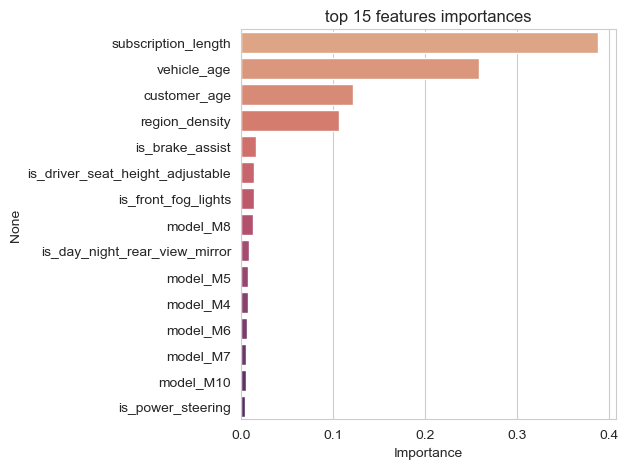

In [248]:
sns.barplot(x= importances.values[:15], y=importances.index[:15], palette="flare")

plt.title("top 15 features importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [249]:
import joblib

joblib.dump(best_model, "claim_model.pkl")
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")
joblib.dump(sorted(df_clean["model"].unique().tolist()), "model_options.pkl")

['model_options.pkl']

lưu lại mô hình tốt nhất (best_model) cùng với các cấu hình dữ liệu quan trọng ra ổ cứng dưới dạng các tệp nhị phân (.pkl), sẵn sàng cho việc đưa mô hình vào ứng dụng thực tế (như làm web app dự đoán, API, hoặc giao diện Streamlit).

joblib.dump(best_model, "claim_model.pkl")

Lưu toàn bộ mô hình vô địch (best_model) vào tệp tên là "claim_model.pkl". Tệp này lưu giữ toàn bộ các cấu trúc cây, trọng số và quy tắc phân loại đã học được. Sau này bạn chỉ cần gọi lệnh joblib.load("claim_model.pkl") là có thể mang đi dự đoán ngay lập tức mà không cần phải chạy lại quá trình fit() mất thời gian.

joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

Lưu lại danh sách tên các cột đặc trưng (X_train.columns) dưới dạng một danh sách Python (tolist()) vào tệp "model_columns.pkl".

Ý nghĩa thực tế: Đây là một kinh nghiệm sống còn khi triển khai mô hình. Khi có một khách hàng mới nhập dữ liệu vào để dự đoán gian lận, bạn phải ép dữ liệu mới có đúng thứ tự và tên các cột y hệt như lúc train. Tệp này giúp bạn kiểm tra và khớp lại danh sách cột để tránh việc mô hình bị lỗi do thiếu cột hoặc sai thứ tự đặc trưng.

joblib.dump(sorted(df_clean["model"].unique().tolist()), "model_options.pkl")

Trích xuất danh sách tất cả các dòng xe độc nhất (unique()) có trong cột model, sắp xếp chúng theo bảng chữ cái (sorted()), chuyển thành dạng list và lưu vào tệp "model_options.pkl".

Ý nghĩa thực tế: Nếu bạn làm giao diện web (như Streamlit hoặc Flask), bạn sẽ cần tệp này để tạo ra một ô chọn (Dropdown/Selectbox) các dòng xe cho người dùng chọn đúng tên xe, đồng thời đảm bảo hệ thống mã hóa One-Hot Encoding hoạt động chuẩn xác với dữ liệu thực tế sau này.